<div >
<img src = "../banner.jpg" />
</div>

<a target="_blank" href="https://colab.research.google.com/github/ignaciomsarmiento/BDML_2026_20/blob/main/Lecture01/L01_01_LR.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Predicción con modelos lineales

Nuestro objetivo  es construir un modelo predictivo de salario

$$
w = f(X) + u
$$

Donde w es el salario y X es una matriz que incluye posibles variables/predictores explicativas (ej. educación, edad, educación de los padres, habilidad cognitiva, etc.). 

Un ejemplo de modelo predictivo es un modelo lineal en parámetros:

$$
ln(w)  = \beta_0 + \beta_1 X_1 + \dots + \beta_p X_p + u
$$

donde $ln(w)$ es el logaritmo del salario.

Para ilustrar, usaré una muestra del NLSY97. El NLSY97 es una muestra representativa a nivel nacional de 8.984 hombres y mujeres nacidos entre 1980 y 1984 y que vivían en los Estados Unidos durante la encuesta inicial de 1997. Los participantes tenían entre 12 y 16 años al 31 de diciembre de 1996. Las entrevistas se realizaron anualmente desde 1997 hasta 2011 y cada dos años desde entonces.

Carguemos los paquetes.

In [ ]:
# install.packages("pacman") #Correr esta linea en Google Colab

In [1]:
# Cargamos los paquetes

require("pacman")

p_load("tidyverse","stargazer")


Loading required package: pacman



Cargamos la base:

In [2]:
nlsy <- read_csv('https://raw.githubusercontent.com/ignaciomsarmiento/datasets/main/nlsy97.csv')

#Housekeeping
nlsy <- nlsy  %>%   drop_na(educ) #dropea los valores faltantes (NA)

Rows: 1266 Columns: 994
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
dbl (994): lnw_2016, educ, black, hispanic, other, exp, afqt, mom_educ, dad_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
head(nlsy)

lnw_2016,educ,black,hispanic,other,exp,afqt,mom_educ,dad_educ,yhea_100_1997,⋯,_XPexp_13,_XPexp_14,_XPexp_16,_XPexp_17,_XPexp_18,_XPexp_19,_XPexp_20,_XPexp_21,_XPexp_22,_XPexp_23
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4.076898,16,0,0,0,11,7.0724,12,12,3,⋯,0,0,0,0,0,0,0,0,0,0
3.294138,9,0,0,0,19,4.7481,9,10,2,⋯,0,0,0,0,0,1,0,0,0,0
2.830896,9,0,1,0,22,1.1987,12,9,3,⋯,0,0,0,0,0,0,0,0,1,0
4.306459,16,0,0,0,13,8.9321,16,18,2,⋯,1,0,0,0,0,0,0,0,0,0
5.991465,16,0,1,0,15,2.2618,16,16,1,⋯,0,0,0,0,0,0,0,0,0,0
4.711924,16,0,0,0,14,8.9502,18,20,1,⋯,0,1,0,0,0,0,0,0,0,0


In [4]:
dim(nlsy)

[1] 1266  994

## Regresión Lineal

In [5]:
reg1 <- lm(lnw_2016~educ,   data = nlsy)

In [6]:
stargazer(reg1,type="text") #Similar en stata: outreg2 


                        Dependent variable:    
                    ---------------------------
                             lnw_2016          
-----------------------------------------------
educ                         0.077***          
                              (0.008)          
                                               
Constant                     2.003***          
                              (0.119)          
                                               
-----------------------------------------------
Observations                   1,266           
R2                             0.067           
Adjusted R2                    0.066           
Residual Std. Error      0.840 (df = 1264)     
F Statistic          90.128*** (df = 1; 1264)  
Note:               *p<0.1; **p<0.05; ***p<0.01


## Predicción

$$
\hat{y} = \hat{\beta}_0 +  \hat{\beta}_1 educ 
$$

In [8]:
str(reg1)

List of 12
 $ coefficients : Named num [1:2] 2.0031 0.0773
  ..- attr(*, "names")= chr [1:2] "(Intercept)" "educ"
 $ residuals    : Named num [1:1266] 0.837 0.595 0.132 1.066 2.751 ...
  ..- attr(*, "names")= chr [1:1266] "1" "2" "3" "4" ...
 $ effects      : Named num [1:1266] -110.6517 7.9759 0.0808 1.052 2.737 ...
  ..- attr(*, "names")= chr [1:1266] "(Intercept)" "educ" "" "" ...
 $ rank         : int 2
 $ fitted.values: Named num [1:1266] 3.24 2.7 2.7 3.24 3.24 ...
  ..- attr(*, "names")= chr [1:1266] "1" "2" "3" "4" ...
 $ assign       : int [1:2] 0 1
 $ qr           :List of 5
  ..$ qr   : num [1:1266, 1:2] -35.5809 0.0281 0.0281 0.0281 0.0281 ...
  .. ..- attr(*, "dimnames")=List of 2
  .. .. ..$ : chr [1:1266] "1" "2" "3" "4" ...
  .. .. ..$ : chr [1:2] "(Intercept)" "educ"
  .. ..- attr(*, "assign")= int [1:2] 0 1
  ..$ qraux: num [1:2] 1.03 1.05
  ..$ pivot: int [1:2] 1 2
  ..$ tol  : num 1e-07
  ..$ rank : int 2
  ..- attr(*, "class")= chr "qr"
 $ df.residual  : int 1264
 $

In [9]:
reg1$coef[1]

(Intercept) 
   2.003074

In [10]:
reg1$coef[2]

educ 
0.07732004

In [11]:
reg1$coef[1]+reg1$coef[2]*16

(Intercept) 
   3.240194

In [12]:
exp(reg1$coef[1]+reg1$coef[2]*16)

(Intercept) 
   25.53869

## Modelando $E(y|X)$

In [13]:
#predict me simplifica hacer la operación X\hat{\beta}

nlsy <- nlsy  %>% mutate(yhat=predict(reg1)) #con la función mutate
head(nlsy %>% select(lnw_2016,yhat))

lnw_2016,yhat
<dbl>,<dbl>
4.076898,3.240194
3.294138,2.698954
2.830896,2.698954
4.306459,3.240194
5.991465,3.240194
4.711924,3.240194


In [14]:


# Voy a calcular E(y|X=x) y E(\hat(y)| X=x)

summ <- nlsy %>%  
  group_by(
    educ
  ) %>%  
  summarize(
    mean_y = mean(lnw_2016),
    yhat_reg = mean(yhat), .groups="drop"
  ) 

In [15]:
head(summ)

educ,mean_y,yhat_reg
<dbl>,<dbl>,<dbl>
8,2.893439,2.621634
9,2.660140,2.698954
10,2.592467,2.776274
11,2.862028,2.853594
12,2.948959,2.930914
13,3.080338,3.008234


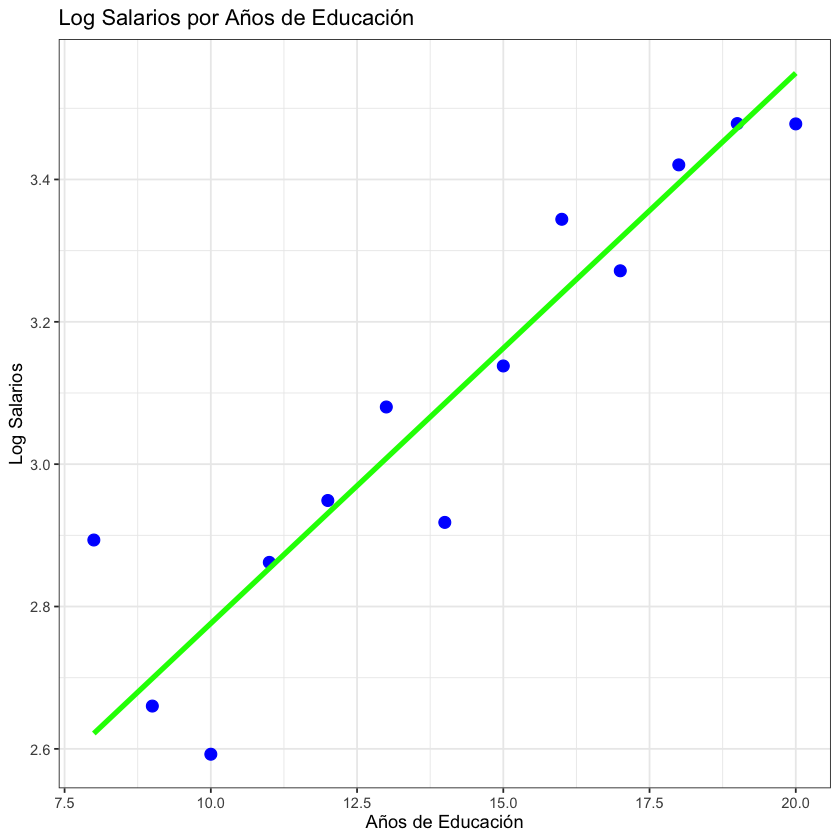

In [16]:
# graficamos
ggplot(summ) + 
  geom_point(
    aes(x = educ, y = mean_y),
    color = "blue", size = 3
  ) + 
  geom_line(
    aes(x = educ, y = yhat_reg), 
    color = "green", linewidth = 1.5
  ) + 
  labs(
    title = "Log Salarios por Años de Educación",
    x = "Años de Educación",
    y = "Log Salarios"
  ) +
  theme_bw()

Vamos a constuir regresores polinomiales de forma tal de tener reglas de predicción más flexibles y potencialmente mejores.

In [17]:
#Polinomios de educación

nlsy <- nlsy  %>% mutate(educ2=educ^2,
                         educ3=educ^3,
                         educ4=educ^4,
                         educ5=educ^5,
                         educ6=educ^6,
                         educ7=educ^7,
                         educ8=educ^8
                        )

In [19]:
head(nlsy)

lnw_2016,educ,black,hispanic,other,exp,afqt,mom_educ,dad_educ,yhea_100_1997,⋯,_XPexp_22,_XPexp_23,yhat,educ2,educ3,educ4,educ5,educ6,educ7,educ8
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4.076898,16,0,0,0,11,7.0724,12,12,3,⋯,0,0,3.240194,256,4096,65536,1048576,16777216,268435456,4294967296
3.294138,9,0,0,0,19,4.7481,9,10,2,⋯,0,0,2.698954,81,729,6561,59049,531441,4782969,43046721
2.830896,9,0,1,0,22,1.1987,12,9,3,⋯,1,0,2.698954,81,729,6561,59049,531441,4782969,43046721
4.306459,16,0,0,0,13,8.9321,16,18,2,⋯,0,0,3.240194,256,4096,65536,1048576,16777216,268435456,4294967296
5.991465,16,0,1,0,15,2.2618,16,16,1,⋯,0,0,3.240194,256,4096,65536,1048576,16777216,268435456,4294967296
4.711924,16,0,0,0,14,8.9502,18,20,1,⋯,0,0,3.240194,256,4096,65536,1048576,16777216,268435456,4294967296


 Corremos la regresión

In [20]:
reg2 <- lm(lnw_2016~educ+ educ2 + educ3 + educ4 + educ5 + educ6 + educ7 + 
    educ8 ,   data = nlsy)


In [21]:
stargazer(reg1,reg2,type="text") #Similar en stata: outreg2 


                                   Dependent variable:               
                    -------------------------------------------------
                                        lnw_2016                     
                              (1)                      (2)           
---------------------------------------------------------------------
educ                        0.077***                3,798.831*       
                            (0.008)                (2,157.819)       
                                                                     
educ2                                              -1,040.673*       
                                                    (578.718)        
                                                                     
educ3                                                160.193*        
                                                     (87.500)        
                                                                     
educ4              

In [22]:
#predict me simplifica hacer la operación X\hat{\beta}

nlsy <- nlsy  %>% mutate(yhat_2=predict(reg2)) #con la función mutate


In [23]:
head(nlsy)

lnw_2016,educ,black,hispanic,other,exp,afqt,mom_educ,dad_educ,yhea_100_1997,⋯,_XPexp_23,yhat,educ2,educ3,educ4,educ5,educ6,educ7,educ8,yhat_2
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
4.076898,16,0,0,0,11,7.0724,12,12,3,⋯,0,3.240194,256,4096,65536,1048576,16777216,268435456,4294967296,3.311502
3.294138,9,0,0,0,19,4.7481,9,10,2,⋯,0,2.698954,81,729,6561,59049,531441,4782969,43046721,2.661006
2.830896,9,0,1,0,22,1.1987,12,9,3,⋯,0,2.698954,81,729,6561,59049,531441,4782969,43046721,2.661006
4.306459,16,0,0,0,13,8.9321,16,18,2,⋯,0,3.240194,256,4096,65536,1048576,16777216,268435456,4294967296,3.311502
5.991465,16,0,1,0,15,2.2618,16,16,1,⋯,0,3.240194,256,4096,65536,1048576,16777216,268435456,4294967296,3.311502
4.711924,16,0,0,0,14,8.9502,18,20,1,⋯,0,3.240194,256,4096,65536,1048576,16777216,268435456,4294967296,3.311502


In [24]:
# Voy a calcular E(y|X=x) y E(\hat(y)| X=x)

summ <- nlsy %>%  
  group_by(
    educ, educ2, educ3, educ4, educ5, 
    educ6, educ7, educ8
  ) %>%  
  summarize(
    mean_y = mean(lnw_2016),
      yhat_reg = mean(yhat), 
    yhat_reg_2 = mean(yhat_2), .groups="drop"
  ) 

In [ ]:
head(summ)

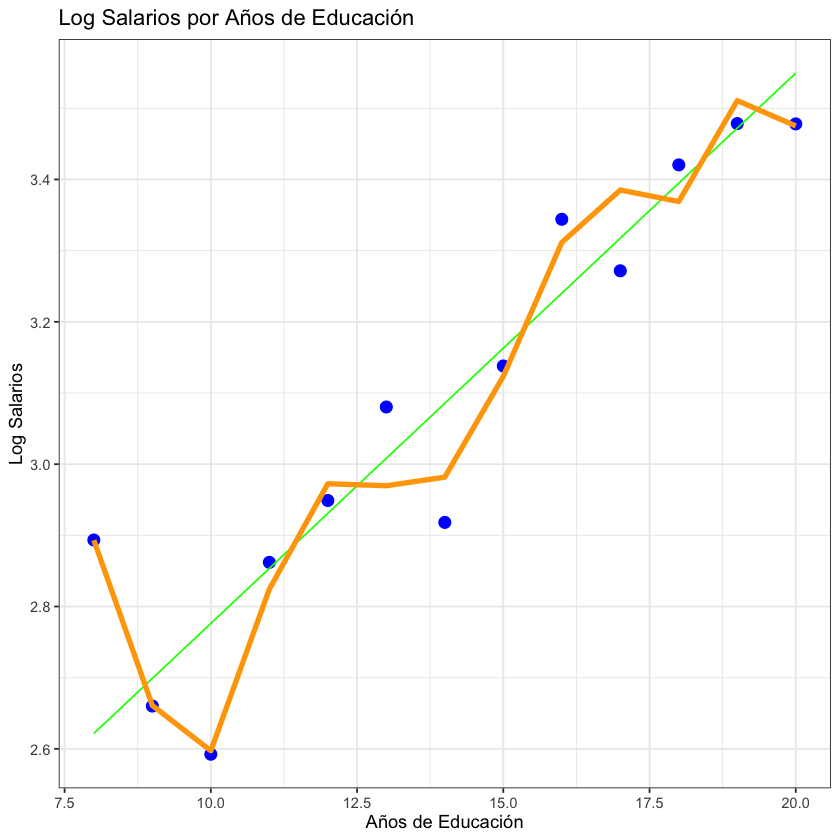

In [25]:
# graficamos
ggplot(summ) + 
  geom_point(
    aes(x = educ, y = mean_y),
    color = "blue", size = 3
  ) + 
  geom_line(
    aes(x = educ, y = yhat_reg), 
    color = "green", linewidth = 0.5
  ) +
geom_line(
    aes(x = educ, y = yhat_reg_2), 
    color = "orange", linewidth = 1.5
  )+ 
  labs(
    title = "Log Salarios por Años de Educación",
    x = "Años de Educación",
    y = "Log Salarios"
  ) +
  theme_bw()


Como podemos ver, este modelo flexible captura muy bien patrones complejos. 

Incluyendo un conjunto lo suficientemente rico de transformaciones, las predicciones de OLS producirán estimaciones del predictor ideal: la función de expectativa condicional.